In [65]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [66]:
import json
import gymnasium as gym
import matplotlib.pyplot as plt

from stable_baselines3.common.evaluation import evaluate_policy

from train.train_cartpole import train_snn_cartpole
from train.train_acrobot import train_snn_acrobot
from train.train_pendulum import train_snn_pendulum
from train.train_ann import train_ann


from nas.run_nas import run_nas
from nas.analyzer import plot_reward_vs_layers, plot_reward_vs_neurons

In [67]:
def evaluate_model(model, env_name, n_eval_episodes=10):

    env = gym.make(env_name)
    env.reset(seed=42)

    mean_reward, std_reward = evaluate_policy(
        model, env, n_eval_episodes=n_eval_episodes, deterministic=True
    )

    return mean_reward, std_reward


def compute_param_count(model):
    return sum(p.numel() for p in model.policy.parameters())


def compute_grad_norm(model):

    total_norm = 0

    for p in model.policy.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2

    return total_norm**0.5


def extract_spike_rate(model):

    extractor = model.policy.features_extractor

    if hasattr(extractor, "latest_spike_rate"):
        return extractor.latest_spike_rate

    return None


results = {}

### CartPole

In [68]:
# print("===== CartPole SNN =====")

# model_snn = train_snn_cartpole()

# mean_snn, std_snn = evaluate_model(model_snn, "CartPole-v1")

# snn_params = compute_param_count(model_snn)
# snn_grad = compute_grad_norm(model_snn)
# snn_spike = extract_spike_rate(model_snn)

# print("Reward:", mean_snn, "±", std_snn)
# print("Parameters:", snn_params)
# print("Gradient Norm:", snn_grad)
# print("Spike Rate:", snn_spike)

In [69]:
# print("===== CartPole ANN =====")

# model_ann = train_ann("CartPole-v1",100_000)

# mean_ann, std_ann = evaluate_model(model_ann, "CartPole-v1")

# ann_params = compute_param_count(model_ann)

# print("Reward:", mean_ann, "±", std_ann)
# print("Parameters:", ann_params)

# results["CartPole-v1"] = {
#     "SNN_reward_mean": mean_snn,
#     "SNN_reward_std": std_snn,
#     "ANN_reward_mean": mean_ann,
#     "ANN_reward_std": std_ann,
#     "SNN_params": snn_params,
#     "ANN_params": ann_params,
#     "SNN_grad_norm": snn_grad,
#     "SNN_spike_rate": snn_spike
# }

### Acrobot

In [70]:
# print("===== Acrobot SNN =====")

# model_snn = train_snn_acrobot()

# mean_snn, std_snn = evaluate_model(model_snn, "Acrobot-v1")

# snn_params = compute_param_count(model_snn)
# snn_grad = compute_grad_norm(model_snn)
# snn_spike = extract_spike_rate(model_snn)

# print("Reward:", mean_snn, "±", std_snn)
# print("Parameters:", snn_params)
# print("Gradient Norm:", snn_grad)
# print("Spike Rate:", snn_spike)

In [71]:
# print("===== Acrobot ANN =====")

# model_ann = train_ann("Acrobot-v1",200_000)

# mean_ann, std_ann = evaluate_model(model_ann, "Acrobot-v1")

# ann_params = compute_param_count(model_ann)

# print("Reward:", mean_ann, "±", std_ann)
# print("Parameters:", ann_params)

# results["Acrobot-v1"] = {
#     "SNN_reward_mean": mean_snn,
#     "SNN_reward_std": std_snn,
#     "ANN_reward_mean": mean_ann,
#     "ANN_reward_std": std_ann,
#     "SNN_params": snn_params,
#     "ANN_params": ann_params,
#     "SNN_grad_norm": snn_grad,
#     "SNN_spike_rate": snn_spike
# }

### Pendulum

In [72]:
# print("===== Pendulum SNN =====")

# model_snn = train_snn_pendulum()

# mean_snn, std_snn = evaluate_model(model_snn, "Pendulum-v1")

# snn_params = compute_param_count(model_snn)
# snn_grad = compute_grad_norm(model_snn)
# snn_spike = extract_spike_rate(model_snn)

# print("Reward:", mean_snn, "±", std_snn)
# print("Parameters:", snn_params)
# print("Gradient Norm:", snn_grad)
# print("Spike Rate:", snn_spike)

In [73]:
# print("===== Pendulum ANN =====")

# model_ann = train_ann("Pendulum-v1",200_000)

# mean_ann, std_ann = evaluate_model(model_ann, "Pendulum-v1")

# ann_params = compute_param_count(model_ann)

# print("Reward:", mean_ann, "±", std_ann)
# print("Parameters:", ann_params)

# results["Pendulum-v1"] = {
#     "SNN_reward_mean": mean_snn,
#     "SNN_reward_std": std_snn,
#     "ANN_reward_mean": mean_ann,
#     "ANN_reward_std": std_ann,
#     "SNN_params": snn_params,
#     "ANN_params": ann_params,
#     "SNN_grad_norm": snn_grad,
#     "SNN_spike_rate": snn_spike
# }

### Save Results

In [74]:
# import json

# with open("results/phase2_results.json", "w") as f:
#     json.dump(results, f, indent=4, default=str)

# print("Metrics saved")

In [75]:
# envs = list(results.keys())

# snn_rewards = [results[e]["SNN_reward_mean"] for e in envs]
# ann_rewards = [results[e]["ANN_reward_mean"] for e in envs]

# x = range(len(envs))

# plt.figure()

# plt.bar(x, snn_rewards, width=0.4, label="SNN")
# plt.bar([i + 0.4 for i in x], ann_rewards, width=0.4, label="ANN")

# plt.xticks([i + 0.2 for i in x], envs)

# plt.ylabel("Mean Reward")
# plt.title("SNN vs ANN Performance")

# plt.legend()

# plt.savefig("results/reward_comparison.png")

# plt.show()

In [76]:
# spike_rates = [results[e]["SNN_spike_rate"] for e in envs]

# plt.figure()

# plt.bar(envs, spike_rates)

# plt.ylabel("Spike Rate")
# plt.title("SNN Spike Activity")

# plt.savefig("results/spike_rates.png")

# plt.show()

In [77]:
# snn_params = [results[e]["SNN_params"] for e in envs]
# ann_params = [results[e]["ANN_params"] for e in envs]

# x = range(len(envs))

# plt.figure()

# plt.bar(x, snn_params, width=0.4, label="SNN")
# plt.bar([i + 0.4 for i in x], ann_params, width=0.4, label="ANN")

# plt.xticks([i + 0.2 for i in x], envs)

# plt.ylabel("Parameter Count")
# plt.title("Model Complexity")

# plt.legend()

# plt.savefig("results/parameter_counts.png")

# plt.show()

## Phase 3

In [78]:
# sample or example of running NAS for CartPole
# study_cartpole = run_nas(env_name="CartPole-v1", n_trials=20)

In [79]:
# Nas for all environments
env = "CartPole-v1"

studies = {}
print(f"Running NAS for {env}...")
studies[env] = run_nas(env_name=env, n_trials=10)

[I 2026-03-26 22:39:01,172] A new study created in memory with name: no-name-8480f6d5-efea-4354-81e2-d598d61d2d6c


Running NAS for CartPole-v1...


[I 2026-03-26 22:40:25,188] Trial 0 finished with value: 29.0 and parameters: {'num_layers': 2, 'neurons_per_layer': 62, 'time_window': 9, 'lif_threshold': 1.397987726295555}. Best is trial 0 with value: 29.0.


Episode reward: 29.0


[I 2026-03-26 22:40:59,932] Trial 1 finished with value: 39.0 and parameters: {'num_layers': 1, 'neurons_per_layer': 23, 'time_window': 5, 'lif_threshold': 1.7992642186624028}. Best is trial 1 with value: 39.0.


...

Episode reward: 14.0


[I 2026-03-26 22:47:55,199] Trial 8 finished with value: 14.0 and parameters: {'num_layers': 1, 'neurons_per_layer': 62, 'time_window': 10, 'lif_threshold': 1.7125960221746916}. Best is trial 3 with value: 68.0.


Episode reward: 14.0


[I 2026-03-26 22:48:44,299] Trial 9 finished with value: 17.0 and parameters: {'num_layers': 1, 'neurons_per_layer': 20, 'time_window': 9, 'lif_threshold': 1.1602287406094018}. Best is trial 3 with value: 68.0.


Episode reward: 17.0
Best trial for CartPole-v1: {'num_layers': 3, 'neurons_per_layer': 26, 'time_window': 6, 'lif_threshold': 0.7751067647801507}
Best reward: 68.0


Analyzing CartPole-v1


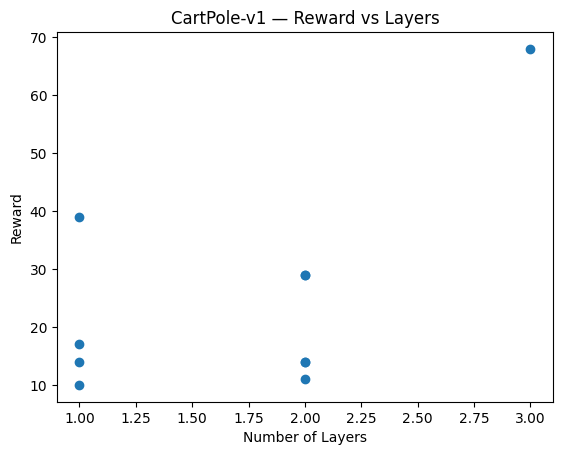

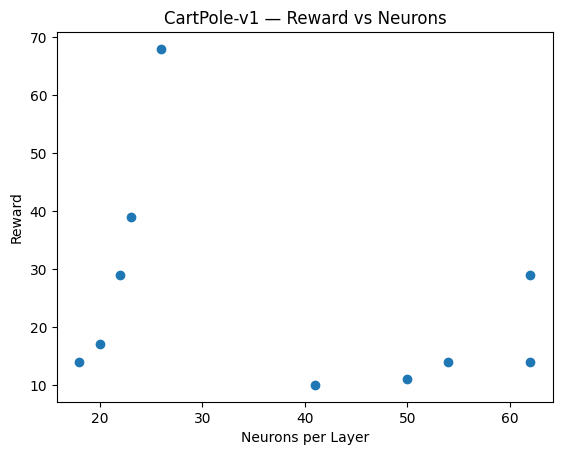

In [80]:
# Analyze NAS results

print(f"Analyzing {env}")
plot_reward_vs_layers(env)
plot_reward_vs_neurons(env)

In [81]:
# run.ipynb
best_params = studies[env].best_trial.params
best_reward = studies[env].best_trial.value
best_param_count = studies[env].best_trial.user_attrs.get("param_count")
print(
    f"{env}: Best Reward={best_reward}, Params={best_params}, Param Count={best_param_count}"
)

CartPole-v1: Best Reward=68.0, Params={'num_layers': 3, 'neurons_per_layer': 26, 'time_window': 6, 'lif_threshold': 0.7751067647801507}, Param Count=22047


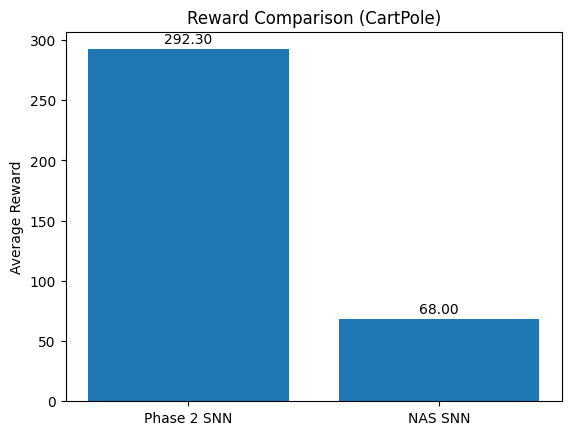

In [82]:
import matplotlib.pyplot as plt

with open("results/phase2_results.json", "r") as f:
    data = json.load(f)
phase2_reward = data["CartPole-v1"]["SNN_reward_mean"]
# Data
labels = ["Phase 2 SNN", "NAS SNN"]
rewards = [phase2_reward, best_reward]

# Plot
plt.figure()
plt.bar(labels, rewards)

plt.title("Reward Comparison (CartPole)")
plt.ylabel("Average Reward")

for i, v in enumerate(rewards):
    plt.text(i, v + 5, f"{v:.2f}", ha="center")

plt.show()

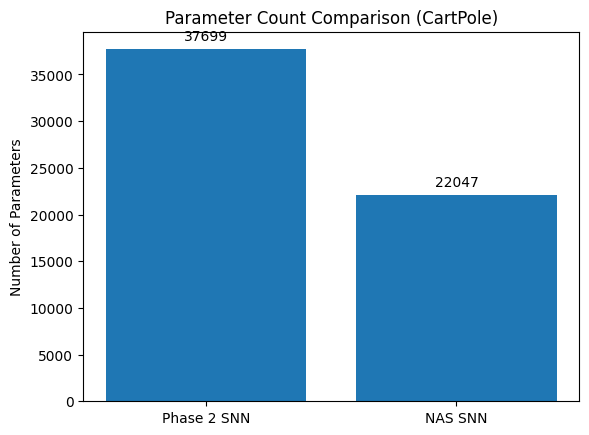

In [83]:
# Data
with open("results/phase2_results.json", "r") as f:
    data = json.load(f)
phase2_params = data["CartPole-v1"]["SNN_params"]

best_param_count = studies[env].best_trial.user_attrs.get("param_count")
if best_param_count is None:
    best_param_count = next(
        (
            t.user_attrs.get("param_count")
            for t in studies[env].trials
            if t.user_attrs.get("param_count") is not None
        ),
        None,
    )
    if best_param_count is not None:
        print(
            f"Warning: best_trial.user_attrs.param_count is missing; using first available trial param_count={best_param_count}."
        )
    else:
        print(
            "Warning: no param_count found in any trial; using phase2 value for comparison."
        )
        best_param_count = phase2_params

params = [phase2_params, best_param_count]

# Plot
plt.figure()
plt.bar(labels, params)

plt.title("Parameter Count Comparison (CartPole)")
plt.ylabel("Number of Parameters")

for i, v in enumerate(params):
    plt.text(i, v + 1000, f"{v}", ha="center")

plt.show()

In [84]:
ratio1 = phase2_reward / phase2_params
ratio2 = best_reward / best_param_count
print("Phase 2 SNN:", ratio1)
print("NAS SNN:", ratio2)

Phase 2 SNN: 0.007753521313562694
NAS SNN: 0.003084319862112759
